In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install -q lime joblib pyarrow xgboost torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# 03b — LIME Explanations

Computes per-replica LIME attributions on a subsample of the flagged set F_{A,B}
for all three model types. Drops into notebook 04's drift code identically to SHAP,
just under `data/lime/{MODEL_TYPE}/pair_XX/`.

## Scope decisions

| Decision | Value | Why |
|---|---|---|
| Explainer | `lime.lime_tabular.LimeTabularExplainer` | Standard choice for tabular |
| Instances per pair | `N_LIME_SUBSAMPLE = 200` | Flagged-set subsample; keeps runtime tractable |
| Perturbations per instance | `num_samples = 1000` | Paper default 5000; 1000 ≈ 90% as stable at 5× speedup |
| Features returned | all features | Needed for full cosine + RBO over the complete attribution vector |
| Sampling basis | **Per-window training data, raw** | A replicas explained against `X[idx_A]`; B against `X[idx_B]` |
| Categorical declarations | binary columns | LIME samples these from the empirical distribution |

## Per-model-type specifics

All `predict_proba` callables receive **raw** feature input. Each replica's own pipeline /
scaler handles whatever scaling the model needs internally — LIME never pre-scales.

- **XGBoost**: `predict_proba` consumes raw input directly.
- **LR**: each replica is a `Pipeline(StandardScaler, LogisticRegression)`; the pipeline scales internally.
- **MLP-PLR**: `predict_proba` wraps the model with its replica scaler and pushes batched inputs to GPU.

## Output layout

```
data/lime/{MODEL_TYPE}/pair_{pid:02d}/
  lime_A.npy                 # (R, |F_lime|, p), float32
  lime_B.npy                 # same
  lime_flagged_idx.npy       # (|F_lime|,) int — subsample positions within flagged_idx
  stochasticity.json         # {best_replica_A, max_abs_diff, median_abs_diff, is_deterministic}
  global_importance_pair00_A.png   # top-20 plot for pair 0
```

## Stochasticity note

LIME is more stochastic than both TreeSHAP (deterministic) and GradientExplainer
(mildly stochastic). The `max_abs_diff` in stochasticity.json will be non-zero and
typically larger than SHAP's. This is a central thesis finding, not a bug.


In [3]:
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

import lime
import lime.lime_tabular

WORKSPACE = Path('/content/drive/MyDrive/Homesite_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 / 02b ──
MODEL_TYPE = 'logreg'   # 'xgboost' | 'logreg' | 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
LIME_DIR  = WORKSPACE / 'data' / 'lime'  / MODEL_TYPE
LIME_DIR.mkdir(parents=True, exist_ok=True)

# ── Runtime knobs ──────────────────────────────────────────────────────────
N_LIME_SUBSAMPLE = 200
NUM_SAMPLES      = 1000

from importlib.metadata import version
print(f'lime version: {version("lime")}')
print(f'MODEL_TYPE  : {MODEL_TYPE}')
print(f'N_LIME_SUBSAMPLE: {N_LIME_SUBSAMPLE}  NUM_SAMPLES: {NUM_SAMPLES}')

lime version: 0.2.0.1
MODEL_TYPE  : logreg
N_LIME_SUBSAMPLE: 200  NUM_SAMPLES: 1000


In [4]:
# Load data and window config
X = pd.read_parquet(PROC_DIR / 'X.parquet').values.astype(np.float32)

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)
feature_names = feature_names_json['all']
num_col_idx   = [feature_names.index(c) for c in feature_names_json['num']]
bin_col_idx   = [feature_names.index(c) for c in feature_names_json['bin']]

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)
R     = config['parameters']['R']
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, {len(pairs)} pairs')

X: (260753, 317), features: 317
R=3, 5 pairs


## MLP-PLR setup (only when MODEL_TYPE == 'mlp_plr')

Architecture must be byte-identical to notebook 02b.

In [5]:
if MODEL_TYPE == 'mlp_plr':
    import math
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    assert torch.cuda.is_available(), 'MLP-PLR LIME requires a GPU runtime.'
    DEVICE = torch.device('cuda')
    print(f'Device: {torch.cuda.get_device_name(0)}')

    class PLREmbedding(nn.Module):
        def __init__(self, n_features, k, d_emb, sigma_init):
            super().__init__()
            self.n_features = n_features
            self.k          = k
            self.d_emb      = d_emb
            self.freqs  = nn.Parameter(torch.randn(n_features, k) * sigma_init)
            self.weight = nn.Parameter(torch.empty(n_features, 2 * k, d_emb))
            self.bias   = nn.Parameter(torch.zeros(n_features, d_emb))
            nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

        def forward(self, x_num):
            scaled = 2 * math.pi * x_num.unsqueeze(-1) * self.freqs
            periodic = torch.cat([torch.sin(scaled), torch.cos(scaled)], dim=-1)
            out = torch.einsum('bpd,pde->bpe', periodic, self.weight) + self.bias
            return F.relu(out).flatten(start_dim=1)

    class MLPPLR(nn.Module):
        def __init__(self, n_num, n_bin, k, d_emb, sigma_init, n_blocks, d_block, dropout):
            super().__init__()
            self.n_num = n_num
            self.n_bin = n_bin
            if n_num > 0:
                self.embedding = PLREmbedding(n_num, k, d_emb, sigma_init)
                input_dim = n_num * d_emb + n_bin
            else:
                self.embedding = None
                input_dim = n_bin
            layers = []
            d_in = input_dim
            for _ in range(n_blocks):
                layers.append(nn.Linear(d_in, d_block))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
                d_in = d_block
            layers.append(nn.Linear(d_in, 1))
            self.backbone = nn.Sequential(*layers)

        def forward(self, x_num, x_bin):
            if self.embedding is not None:
                emb = self.embedding(x_num)
                h = torch.cat([emb, x_bin], dim=1) if self.n_bin > 0 else emb
            else:
                h = x_bin
            return self.backbone(h).squeeze(-1)

    def load_mlp_plr_replica(bundle_path, device):
        bundle = joblib.load(bundle_path)
        m = MLPPLR(**bundle['arch_config'])
        m.load_state_dict(bundle['state_dict'])
        m.to(device).eval()
        return m, bundle['scaler']

    def make_mlp_predict_proba(model, replica_scaler, num_idx, bin_idx, device,
                               batch_size: int = 4096):
        """LIME-compatible predict_proba: takes raw (n, p), returns (n, 2)."""
        num_idx_arr = np.asarray(num_idx, dtype=np.int64)
        bin_idx_arr = np.asarray(bin_idx, dtype=np.int64)

        def _predict(X_np: np.ndarray) -> np.ndarray:
            X_sc = X_np.astype(np.float32, copy=True)
            X_sc[:, num_idx_arr] = replica_scaler.transform(X_np[:, num_idx_arr])
            out = np.empty(X_sc.shape[0], dtype=np.float32)
            for start in range(0, X_sc.shape[0], batch_size):
                chunk = X_sc[start:start + batch_size]
                xn = torch.from_numpy(chunk[:, num_idx_arr]).float().to(device)
                xb = torch.from_numpy(chunk[:, bin_idx_arr]).float().to(device)
                with torch.no_grad():
                    logit = model(xn, xb)
                    probs = torch.sigmoid(logit).cpu().numpy()
                out[start:start + len(chunk)] = probs
            return np.stack([1.0 - out, out], axis=1)
        return _predict

    print('MLP-PLR setup complete.')

## LIME helpers — explainer construction + attribution extraction

In [6]:
def build_lime_explainer(training_data, feature_names, bin_col_idx, seed):
    return lime.lime_tabular.LimeTabularExplainer(
        training_data         = training_data,
        feature_names         = feature_names,
        categorical_features  = bin_col_idx,
        class_names           = ['neg', 'pos'],
        discretize_continuous = False,
        sample_around_instance= True,
        mode                  = 'classification',
        random_state          = seed,
    )


def extract_lime_vector(lime_exp, n_features: int) -> np.ndarray:
    """LIME's `as_map()` returns {label: [(feat_idx, weight), ...]}; we take the
    positive-class label and pad to a full (n_features,) vector."""
    out = np.zeros(n_features, dtype=np.float32)
    m = lime_exp.as_map()
    label = max(m.keys()) if m else 1
    for feat_idx, w in m.get(label, []):
        out[feat_idx] = w
    return out


def build_subsample_idx(flagged_local_idx, p_hat_A, p_hat_B,
                        n_subsample: int, seed: int) -> np.ndarray:
    """Stable subsample of flagged positions per pair (uses pid-derived seed)."""
    n_flagged = len(flagged_local_idx)
    if n_flagged <= n_subsample:
        return np.arange(n_flagged, dtype=np.int64)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_flagged, size=n_subsample, replace=False)).astype(np.int64)

## Per-model-type predict_proba builders

XGBoost reads from raw input; LR is a Pipeline that scales internally; MLP-PLR uses the helper above.

In [7]:
SEED_BASE = 42

def get_predict_proba_for_replica(pair_dir, AB, r):
    """Return (predict_fn, cleanup_handle). cleanup_handle is the model object so
    callers can `del` it after use (matters for MLP-PLR / GPU memory)."""

    if MODEL_TYPE == 'xgboost':
        import xgboost as xgb
        booster = joblib.load(pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib')

        def _predict(X_np: np.ndarray) -> np.ndarray:
            d = xgb.DMatrix(X_np.astype(np.float32))
            p = booster.predict(d)
            return np.stack([1.0 - p, p], axis=1)
        return _predict, booster

    if MODEL_TYPE == 'logreg':
        pipe = joblib.load(pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib')

        def _predict(X_np: np.ndarray) -> np.ndarray:
            return pipe.predict_proba(X_np.astype(np.float32))
        return _predict, pipe

    if MODEL_TYPE == 'mlp_plr':
        bundle_path = pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib'
        model, scaler = load_mlp_plr_replica(bundle_path, DEVICE)
        predict_fn = make_mlp_predict_proba(model, scaler, num_col_idx, bin_col_idx, DEVICE)
        return predict_fn, model

    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')

## Main LIME computation loop

For each pair: subsample the flagged set, build per-window LIME explainers from raw
training data, and compute LIME vectors per replica per instance.

In [8]:
for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    lime_pair = LIME_DIR  / f'pair_{pid:02d}'
    lime_pair.mkdir(parents=True, exist_ok=True)

    lime_A_path     = lime_pair / 'lime_A.npy'
    lime_B_path     = lime_pair / 'lime_B.npy'
    subsample_path  = lime_pair / 'lime_flagged_idx.npy'

    if lime_A_path.exists() and lime_B_path.exists() and subsample_path.exists():
        print(f'Pair {pid:02d}: LIME already computed, skipping.')
        continue

    print(f'\n── Pair {pid:02d}  ({MODEL_TYPE}) ──')

    pred_data         = np.load(pair_dir / 'predictions.npz')
    idx_A             = np.array(p['idx_A'],    dtype=np.int64)
    idx_B             = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
    flagged_local_idx = pred_data['flagged_idx']
    p_hat_A           = pred_data['p_hat_A']
    p_hat_B           = pred_data['p_hat_B']

    if len(flagged_local_idx) == 0:
        print('  No flagged instances — writing empty arrays.')
        np.save(lime_A_path, np.zeros((R, 0, X.shape[1]), dtype=np.float32))
        np.save(lime_B_path, np.zeros((R, 0, X.shape[1]), dtype=np.float32))
        np.save(subsample_path, np.zeros(0, dtype=np.int64))
        continue

    lime_sub = build_subsample_idx(flagged_local_idx, p_hat_A, p_hat_B,
                                   n_subsample=N_LIME_SUBSAMPLE,
                                   seed=SEED_BASE + pid * 100)
    n_lime = len(lime_sub)
    print(f'  Flagged: {len(flagged_local_idx):,}  LIME subsample: {n_lime}')
    np.save(subsample_path, lime_sub)

    flagged_global_idx = idx_eval[flagged_local_idx]
    X_explain          = X[flagged_global_idx[lime_sub]]   # (n_lime, p) RAW
    n_feat             = X_explain.shape[1]

    X_basis_A = X[idx_A]   # raw — LIME sampling basis for A-window explainer
    X_basis_B = X[idx_B]   # raw — LIME sampling basis for B-window explainer

    explainer_A = build_lime_explainer(
        training_data=X_basis_A, feature_names=feature_names,
        bin_col_idx=bin_col_idx, seed=SEED_BASE + pid * 100 + 1,
    )
    explainer_B = build_lime_explainer(
        training_data=X_basis_B, feature_names=feature_names,
        bin_col_idx=bin_col_idx, seed=SEED_BASE + pid * 100 + 2,
    )
    print(f'  Per-window LIME explainers built: A on {X_basis_A.shape[0]:,} rows, B on {X_basis_B.shape[0]:,} rows')

    lime_A = np.zeros((R, n_lime, n_feat), dtype=np.float32)
    lime_B = np.zeros((R, n_lime, n_feat), dtype=np.float32)

    for AB, base_explainer, out_arr in [
        ('A', explainer_A, lime_A),
        ('B', explainer_B, lime_B),
    ]:
        for r in range(R):
            predict_fn, cleanup = get_predict_proba_for_replica(pair_dir, AB, r)

            for i in range(n_lime):
                exp = base_explainer.explain_instance(
                    data_row     = X_explain[i],
                    predict_fn   = predict_fn,
                    num_features = n_feat,
                    num_samples  = NUM_SAMPLES,
                )
                out_arr[r, i] = extract_lime_vector(exp, n_feat)

            print(f'  {AB} r{r:2d}: mean |LIME| = {float(np.abs(out_arr[r]).mean()):.5f}')

            if MODEL_TYPE == 'mlp_plr':
                del cleanup
                import torch
                torch.cuda.empty_cache()

    np.save(lime_A_path, lime_A)
    np.save(lime_B_path, lime_B)
    print(f'  Saved lime_A {lime_A.shape}, lime_B {lime_B.shape}')

print('\n✓ All LIME attributions computed.')


── Pair 00  (logreg) ──
  Flagged: 2,335  LIME subsample: 200
  Per-window LIME explainers built: A on 71,989 rows, B on 78,443 rows
  A r 0: mean |LIME| = 0.01548
  A r 1: mean |LIME| = 0.01545
  A r 2: mean |LIME| = 0.01564
  B r 0: mean |LIME| = 0.01523
  B r 1: mean |LIME| = 0.01507
  B r 2: mean |LIME| = 0.01509
  Saved lime_A (3, 200, 317), lime_B (3, 200, 317)

── Pair 01  (logreg) ──
  Flagged: 3,072  LIME subsample: 200
  Per-window LIME explainers built: A on 74,193 rows, B on 76,161 rows
  A r 0: mean |LIME| = 0.01568
  A r 1: mean |LIME| = 0.01563
  A r 2: mean |LIME| = 0.01563
  B r 0: mean |LIME| = 0.01489
  B r 1: mean |LIME| = 0.01489
  B r 2: mean |LIME| = 0.01509
  Saved lime_A (3, 200, 317), lime_B (3, 200, 317)

── Pair 02  (logreg) ──
  Flagged: 2,589  LIME subsample: 200
  Per-window LIME explainers built: A on 75,241 rows, B on 74,063 rows
  A r 0: mean |LIME| = 0.01518
  A r 1: mean |LIME| = 0.01505
  A r 2: mean |LIME| = 0.01516
  B r 0: mean |LIME| = 0.01534


## LIME stochasticity diagnostic

Re-run LIME on the same instances with two different seeds for the best A replica.
Compare element-wise.

In [9]:
for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    lime_pair = LIME_DIR  / f'pair_{pid:02d}'

    out_path = lime_pair / 'stochasticity.json'
    if out_path.exists():
        continue

    print(f'\n── Pair {pid:02d} stochasticity ──')

    pred_data = np.load(pair_dir / 'predictions.npz')
    flagged_local_idx = pred_data['flagged_idx']
    idx_A    = np.array(p['idx_A'],    dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    if len(flagged_local_idx) == 0:
        with open(out_path, 'w') as f:
            json.dump({'best_replica_A': 0, 'max_abs_diff': 0.0,
                       'median_abs_diff': 0.0, 'is_deterministic': True}, f, indent=2)
        continue

    subsample_path = lime_pair / 'lime_flagged_idx.npy'
    if not subsample_path.exists():
        print('  lime_flagged_idx.npy missing — skip.')
        continue

    lime_sub = np.load(subsample_path)
    flagged_global_idx = idx_eval[flagged_local_idx]
    X_explain = X[flagged_global_idx[lime_sub]]
    n_feat    = X_explain.shape[1]

    per_rep = pred_data['per_replica_pr_auc_A']
    best_r  = int(np.argmax(per_rep))

    predict_fn, cleanup = get_predict_proba_for_replica(pair_dir, 'A', best_r)

    diffs = []
    for seed_offset in (0, 1):
        explainer = build_lime_explainer(
            training_data=X[idx_A], feature_names=feature_names,
            bin_col_idx=bin_col_idx, seed=SEED_BASE * 7 + pid * 100 + seed_offset,
        )
        run = np.zeros((len(lime_sub), n_feat), dtype=np.float32)
        for i in range(len(lime_sub)):
            exp = explainer.explain_instance(
                data_row=X_explain[i], predict_fn=predict_fn,
                num_features=n_feat, num_samples=NUM_SAMPLES,
            )
            run[i] = extract_lime_vector(exp, n_feat)
        diffs.append(run)

    max_abs_diff    = float(np.abs(diffs[0] - diffs[1]).max())
    median_abs_diff = float(np.median(np.abs(diffs[0] - diffs[1])))

    with open(out_path, 'w') as f:
        json.dump({
            'best_replica_A':   best_r,
            'max_abs_diff':     max_abs_diff,
            'median_abs_diff':  median_abs_diff,
            'is_deterministic': bool(max_abs_diff < 1e-8),
        }, f, indent=2)

    print(f'  best_r={best_r}  max_abs_diff={max_abs_diff:.4f}  median_abs_diff={median_abs_diff:.4f}')

    if MODEL_TYPE == 'mlp_plr':
        del cleanup
        import torch
        torch.cuda.empty_cache()


── Pair 00 stochasticity ──
  best_r=1  max_abs_diff=0.3024  median_abs_diff=0.0075

── Pair 01 stochasticity ──
  best_r=1  max_abs_diff=0.2665  median_abs_diff=0.0076

── Pair 02 stochasticity ──
  best_r=1  max_abs_diff=0.2904  median_abs_diff=0.0072

── Pair 03 stochasticity ──
  best_r=1  max_abs_diff=0.2652  median_abs_diff=0.0078

── Pair 04 stochasticity ──
  best_r=0  max_abs_diff=0.2482  median_abs_diff=0.0071


## Quick LIME summary (pair 0)

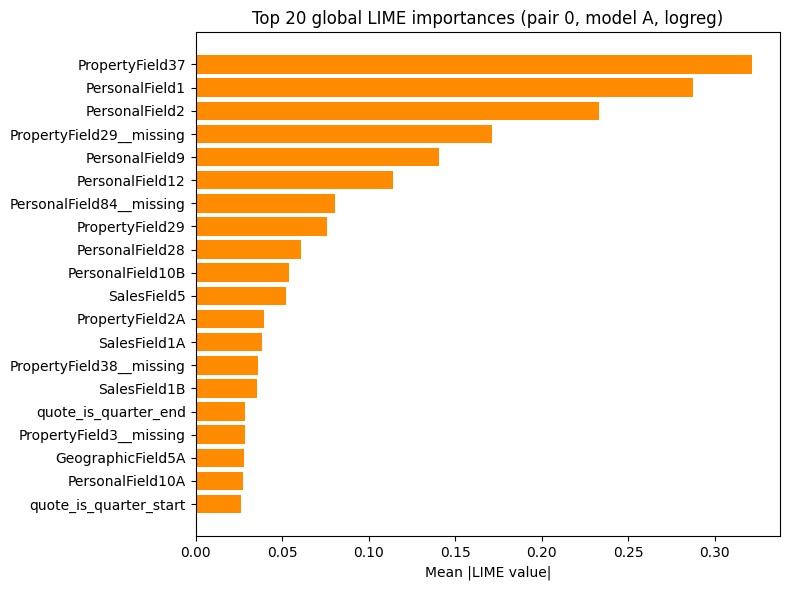

In [10]:
import matplotlib.pyplot as plt

lime_A_0   = np.load(LIME_DIR / 'pair_00' / 'lime_A.npy')   # (R, |F_lime|, p)
phi_bar_A  = lime_A_0.mean(axis=0)                           # (|F_lime|, p)
global_imp = np.abs(phi_bar_A).mean(axis=0)

top_k   = min(20, len(global_imp))
top_idx = np.argsort(global_imp)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    [feature_names[i] for i in top_idx[::-1]],
    global_imp[top_idx[::-1]],
    color='darkorange',
)
ax.set_title(f'Top {top_k} global LIME importances (pair 0, model A, {MODEL_TYPE})')
ax.set_xlabel('Mean |LIME value|')
plt.tight_layout()
plt.savefig(LIME_DIR / 'global_importance_pair00_A.png', dpi=120)
plt.show()